# The Volatility Surface in Practice

## From the Smile to the Full 2D Surface

Previous chapters showed that models like Heston and Merton generate implied-vol **smiles**.
This chapter focuses on how practitioners **describe, quote, and use** the volatility surface:

1. **Why the smile exists** — BS assumes flat vol; real markets disagree by strike
2. **Delta-space quoting** — traders use option delta rather than strike
3. **Risk-reversal & butterfly** — the practitioner vocabulary for skew and curvature
4. **Skew decomposition across maturities** — how RR and BF evolve with $T$
5. **VIX term structure** — the market's fear gauge at different horizons
6. **The full 2D surface** — stacking slices; 3D visualization in strike and delta space
7. **Sticky-strike vs. sticky-delta** — two hedging regimes when spot moves
8. **Real SPY option data** — the surface as seen in live markets

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.interpolate import interp1d, RectBivariateSpline
from math import erf, log, sqrt, exp, pi
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# ── Black-Scholes helpers ──────────────────────────────────────────────────
def bs_cdf(x): return 0.5*(1 + erf(x/sqrt(2)))
def bs_pdf(x): return exp(-x**2/2)/sqrt(2*pi)

def bs_call(S, K, r, T, sigma):
    d1 = (log(S/K)+(r+sigma**2/2)*T)/(sigma*sqrt(T)); d2=d1-sigma*sqrt(T)
    return S*bs_cdf(d1) - K*exp(-r*T)*bs_cdf(d2)

def bs_put(S, K, r, T, sigma):
    d1 = (log(S/K)+(r+sigma**2/2)*T)/(sigma*sqrt(T)); d2=d1-sigma*sqrt(T)
    return -S*bs_cdf(-d1) + K*exp(-r*T)*bs_cdf(-d2)

def bs_vega(S, K, r, T, sigma):
    d1 = (log(S/K)+(r+sigma**2/2)*T)/(sigma*sqrt(T))
    return S*bs_pdf(d1)*sqrt(T)

def bs_delta(S, K, r, T, sigma, is_call=True):
    d1 = (log(S/K)+(r+sigma**2/2)*T)/(sigma*sqrt(T))
    return bs_cdf(d1) if is_call else bs_cdf(d1)-1

def implied_vol_newton(price, S, K, r, T, is_call=True, tol=1e-8, max_iter=100):
    sig = 0.3
    for _ in range(max_iter):
        p = bs_call(S,K,r,T,sig) if is_call else bs_put(S,K,r,T,sig)
        v = bs_vega(S,K,r,T,sig)
        if abs(p-price)<tol: return sig
        if v<1e-12: return np.nan
        sig -= (p-price)/v
        if sig<1e-6: sig=1e-6
    return np.nan

# ── Heston pricer ─────────────────────────────────────────────────────────
def heston_char_func(u, S0, r, T, v0, kappa, theta, xi, rho, j):
    x=np.log(S0); b=kappa-rho*xi if j==1 else kappa; ua=0.5 if j==1 else -0.5
    d=np.sqrt((rho*xi*1j*u-b)**2-xi**2*(2*ua*1j*u-u**2))
    g=(b-rho*xi*1j*u+d)/(b-rho*xi*1j*u-d)
    C=r*1j*u*T+(kappa*theta/xi**2)*((b-rho*xi*1j*u+d)*T-2*np.log((1-g*np.exp(d*T))/(1-g)))
    D=((b-rho*xi*1j*u+d)/xi**2)*((1-np.exp(d*T))/(1-g*np.exp(d*T)))
    return np.exp(C+D*v0+1j*u*x)

def heston_call(S0, K, r, T, v0, kappa, theta, xi, rho):
    def ig(u,j):
        phi=heston_char_func(u,S0,r,T,v0,kappa,theta,xi,rho,j)
        return np.real(np.exp(-1j*u*np.log(K))*phi/(1j*u))
    I1,_=quad(lambda u:ig(u,1),0,200,limit=200)
    I2,_=quad(lambda u:ig(u,2),0,200,limit=200)
    return S0*(0.5+I1/np.pi)-K*np.exp(-r*T)*(0.5+I2/np.pi)

def heston_put(S0, K, r, T, v0, kappa, theta, xi, rho):
    return heston_call(S0,K,r,T,v0,kappa,theta,xi,rho)-S0+K*np.exp(-r*T)

# ── Heston parameters (from Ch.9/10) ──────────────────────────────────────
S0, r_f = 100.0, 0.05
v0, kappa, theta, xi, rho_h = 0.04, 2.0, 0.04, 0.4, -0.7
maturities = [0.1, 0.25, 0.5, 1.0, 2.0]
strikes    = np.linspace(80, 125, 30)

# Pre-compute IV grid
print('Computing Heston IV surface...', end='', flush=True)
market_data = {}
for T_i in maturities:
    F=S0*np.exp(r_f*T_i); ivs=[]
    for Ki in strikes:
        if Ki<S0:
            p=heston_put(S0,Ki,r_f,T_i,v0,kappa,theta,xi,rho_h)
            iv=implied_vol_newton(p,S0,Ki,r_f,T_i,is_call=False)
        else:
            p=heston_call(S0,Ki,r_f,T_i,v0,kappa,theta,xi,rho_h)
            iv=implied_vol_newton(p,S0,Ki,r_f,T_i,is_call=True)
        ivs.append(iv)
    ivs=np.array(ivs); k=np.log(strikes/F)
    market_data[T_i]=(strikes,k,ivs)
print(' done.')
print(f'{len(maturities)} maturities x {len(strikes)} strikes computed')

Computing Heston IV surface...

 done.
5 maturities x 30 strikes computed


## 1. Why the Volatility Smile Exists

Black-Scholes assumes a **constant** $\sigma$ — one vol for all strikes and maturities.
Real markets disagree: OTM puts on equity indices are systematically more expensive
than BS predicts (investors buy them as crash insurance), generating a **skew** or **smile**.

The implied volatility $\sigma_{\text{imp}}(K,T)$ is the value of $\sigma$ that makes
the BS formula match the market price:

$$C_{\text{mkt}}(K,T) = C_{\text{BS}}\bigl(S,K,r,T,\sigma_{\text{imp}}(K,T)\bigr)$$

Plotting $\sigma_{\text{imp}}$ vs. $K$ reveals the **smile** (symmetric curvature)
or **skew** (monotone slope, typical for equity indices).

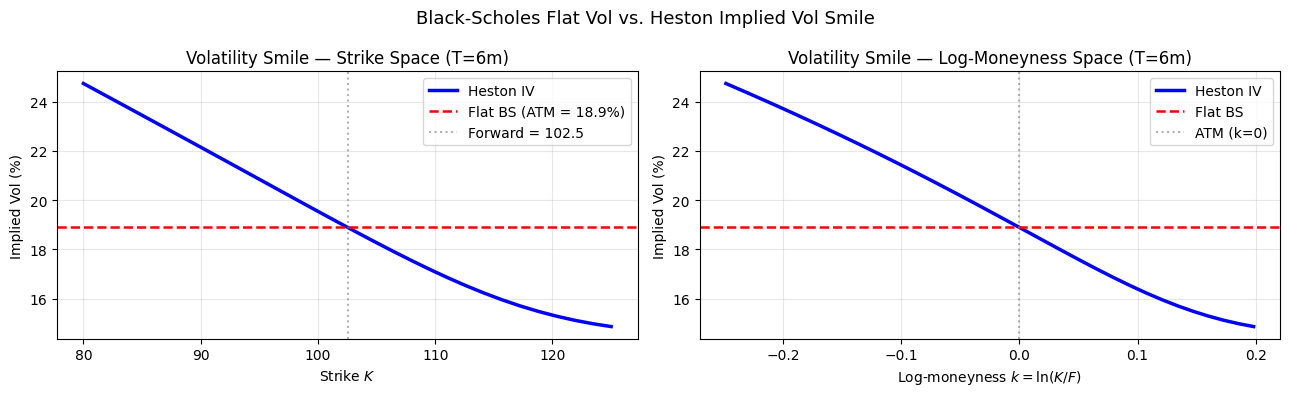

Skew: OTM put (k=-0.15) IV = 22.6% vs ATM = 18.9%  vs OTM call (k=+0.10) IV = 16.4%


In [2]:
T_demo = 0.5
ks, k_arr, ivs = market_data[T_demo]
F_demo = S0*np.exp(r_f*T_demo)

valid = np.isfinite(ivs)
atm_iv = float(np.interp(0.0, k_arr[valid], ivs[valid]))  # IV at k=0

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Strike space
axes[0].plot(ks[valid], ivs[valid]*100, 'b-', linewidth=2.5, label='Heston IV')
axes[0].axhline(atm_iv*100, color='red', linestyle='--', linewidth=1.8,
                label=f'Flat BS (ATM = {atm_iv*100:.1f}%)')
axes[0].axvline(F_demo, color='gray', linestyle=':', alpha=0.6, label=f'Forward = {F_demo:.1f}')
axes[0].set_xlabel('Strike $K$'); axes[0].set_ylabel('Implied Vol (%)')
axes[0].set_title('Volatility Smile — Strike Space (T=6m)')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Log-moneyness space
axes[1].plot(k_arr[valid], ivs[valid]*100, 'b-', linewidth=2.5, label='Heston IV')
axes[1].axhline(atm_iv*100, color='red', linestyle='--', linewidth=1.8, label='Flat BS')
axes[1].axvline(0, color='gray', linestyle=':', alpha=0.6, label='ATM (k=0)')
axes[1].set_xlabel(r'Log-moneyness $k=\ln(K/F)$'); axes[1].set_ylabel('Implied Vol (%)')
axes[1].set_title('Volatility Smile — Log-Moneyness Space (T=6m)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Black-Scholes Flat Vol vs. Heston Implied Vol Smile', fontsize=13)
plt.tight_layout(); plt.show()
print(f'Skew: OTM put (k=-0.15) IV = {np.interp(-0.15,k_arr[valid],ivs[valid])*100:.1f}%'
      f' vs ATM = {atm_iv*100:.1f}%  vs OTM call (k=+0.10) IV = {np.interp(0.10,k_arr[valid],ivs[valid])*100:.1f}%')

## 2. Market Conventions: Delta Space

Practitioners quote vol by **option delta** $\Delta$, not strike — because a given strike
has different moneyness when spot moves. Delta is portable.

For a call under BS: $\Delta_{\text{call}} = N(d_1)$, so ATM-forward is $\Delta=0.5$.

The standard market markers are:

| Marker | Delta (call) | Meaning |
|--------|-------------|---------|
| 25$\Delta$ put | 0.75 | OTM put, $\|\Delta_{\text{put}}\|=0.25$ |
| ATM | 0.50 | At-the-money (forward) |
| 25$\Delta$ call | 0.25 | OTM call |

From these three points we extract two summary statistics:

$$\text{RR}_{25} = \sigma(25\Delta\text{ call}) - \sigma(25\Delta\text{ put})$$
$$\text{BF}_{25} = \frac{\sigma(25\Delta\text{ call})+\sigma(25\Delta\text{ put})}{2} - \sigma_{\text{ATM}}$$

**RR < 0** for equity: OTM puts cost more (crash insurance demand).
**BF > 0**: smile has curvature, not flat wings.

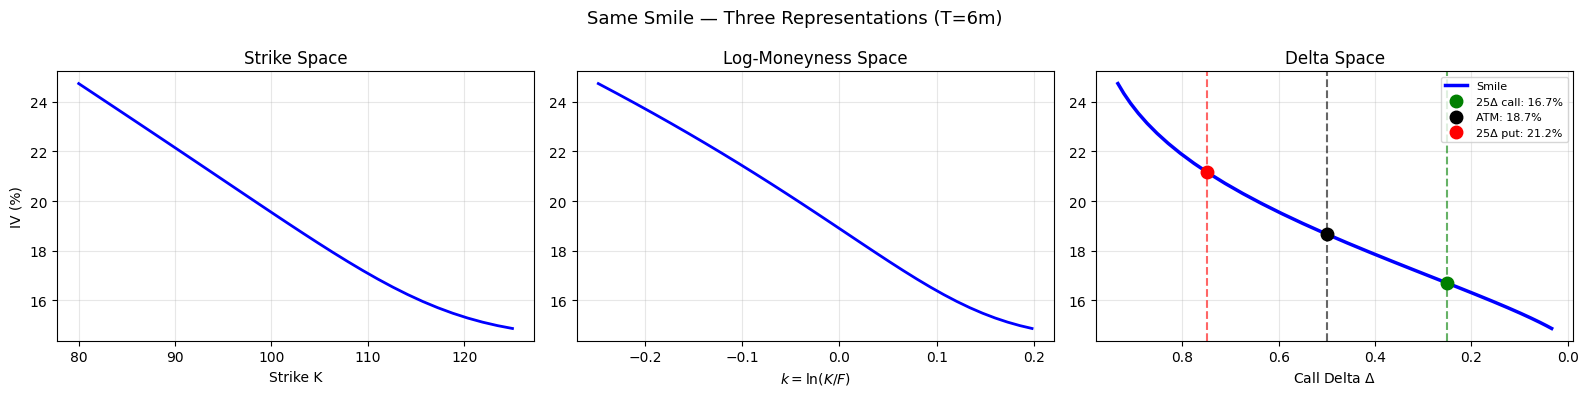

ATM vol  = 18.66%
25Δ call = 16.69%   25Δ put = 21.18%
RR25 = -4.49%  (negative => put skew / equity fear)
BF25 = 0.27%  (positive => smile curvature)


In [3]:
T_demo = 0.5
ks_d, k_arr_d, ivs_d = market_data[T_demo]
valid_d = np.isfinite(ivs_d)
k_v = k_arr_d[valid_d]; iv_v = ivs_d[valid_d]

# Compute call delta for each (K, sigma_imp(K)) pair
deltas = np.array([bs_delta(S0, K, r_f, T_demo, sig) for K, sig in zip(ks_d[valid_d], iv_v)])

# Sort by delta for interpolation
idx = np.argsort(deltas)
d_sorted = deltas[idx]; iv_d_sorted = iv_v[idx]

# Interpolate to standard markers
iv_25c = float(np.interp(0.25, d_sorted, iv_d_sorted))   # 25-delta call
iv_atm = float(np.interp(0.50, d_sorted, iv_d_sorted))   # ATM
iv_25p = float(np.interp(0.75, d_sorted, iv_d_sorted))   # 25-delta put (delta_call=0.75)

rr25 = (iv_25c - iv_25p)*100
bf25 = (0.5*(iv_25c + iv_25p) - iv_atm)*100

# ── Plot: three views ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(ks_d[valid_d], iv_v*100, 'b-', lw=2)
axes[0].set_xlabel('Strike K'); axes[0].set_ylabel('IV (%)')
axes[0].set_title('Strike Space'); axes[0].grid(alpha=0.3)

axes[1].plot(k_v, iv_v*100, 'b-', lw=2)
axes[1].set_xlabel(r'$k=\ln(K/F)$'); axes[1].set_title('Log-Moneyness Space'); axes[1].grid(alpha=0.3)

axes[2].plot(d_sorted, iv_d_sorted*100, 'b-', lw=2.5, label='Smile')
for d_mark, lbl, col in [(0.25,'25Δ call','green'),(0.50,'ATM','black'),(0.75,'25Δ put','red')]:
    iv_mark = float(np.interp(d_mark, d_sorted, iv_d_sorted))
    axes[2].axvline(d_mark, color=col, linestyle='--', alpha=0.6)
    axes[2].plot(d_mark, iv_mark*100, 'o', color=col, markersize=9, label=f'{lbl}: {iv_mark*100:.1f}%')
axes[2].set_xlabel('Call Delta $\Delta$'); axes[2].set_title('Delta Space')
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)
axes[2].invert_xaxis()  # convention: puts on left

plt.suptitle('Same Smile — Three Representations (T=6m)', fontsize=13)
plt.tight_layout(); plt.show()

print(f'ATM vol  = {iv_atm*100:.2f}%')
print(f'25Δ call = {iv_25c*100:.2f}%   25Δ put = {iv_25p*100:.2f}%')
print(f'RR25 = {rr25:.2f}%  (negative => put skew / equity fear)')
print(f'BF25 = {bf25:.2f}%  (positive => smile curvature)')

## 3. Skew Decomposition Across Maturities

ATM vol, RR, and BF all change with maturity — giving insight into how the market
prices near-term vs. long-term risk:

- **ATM vol** tends to **increase with $T$** when the market is calm (vol term structure
  in contango), and **decrease** after a shock (backwardation)
- **|RR|** often **decreases with $T$**: short-dated puts are most expensive relative
  to calls (gamma risk near earnings/events)
- **BF** often **increases with $T$**: longer maturities accumulate more jump risk,
  producing rounder smiles

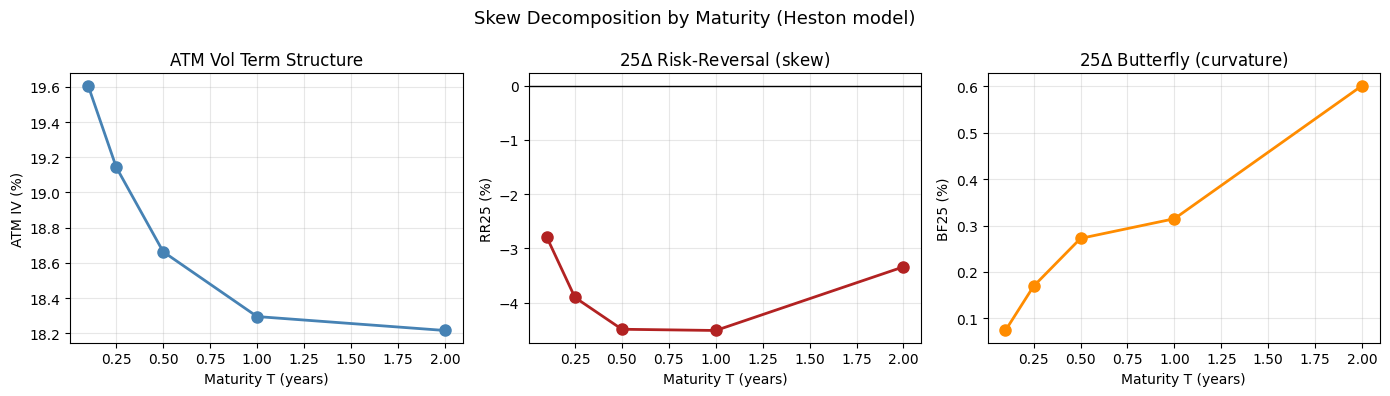

     T       ATM      RR25      BF25
  0.10     19.61%     -2.79%      0.07%
  0.25     19.14%     -3.90%      0.17%
  0.50     18.66%     -4.49%      0.27%
  1.00     18.29%     -4.51%      0.31%
  2.00     18.22%     -3.34%      0.60%


In [4]:
T_arr = np.array(maturities)
atm_vols, rr25s, bf25s = [], [], []

for T_i in maturities:
    _, k_i, iv_i = market_data[T_i]
    valid_i = np.isfinite(iv_i)
    k_vi = k_i[valid_i]; iv_vi = iv_i[valid_i]
    deltas_i = np.array([bs_delta(S0, K, r_f, T_i, sig)
                         for K, sig in zip(strikes[valid_i], iv_vi)])
    idx_i = np.argsort(deltas_i)
    ds = deltas_i[idx_i]; ivs_s = iv_vi[idx_i]
    iv25c = float(np.interp(0.25, ds, ivs_s))
    ivatm = float(np.interp(0.50, ds, ivs_s))
    iv25p = float(np.interp(0.75, ds, ivs_s))
    atm_vols.append(ivatm*100)
    rr25s.append((iv25c-iv25p)*100)
    bf25s.append((0.5*(iv25c+iv25p)-ivatm)*100)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(T_arr, atm_vols, 'o-', lw=2, color='steelblue', markersize=8)
axes[0].set_xlabel('Maturity T (years)'); axes[0].set_ylabel('ATM IV (%)')
axes[0].set_title('ATM Vol Term Structure'); axes[0].grid(alpha=0.3)

axes[1].plot(T_arr, rr25s, 'o-', lw=2, color='firebrick', markersize=8)
axes[1].axhline(0, color='black', lw=1)
axes[1].set_xlabel('Maturity T (years)'); axes[1].set_ylabel('RR25 (%)')
axes[1].set_title('25$\Delta$ Risk-Reversal (skew)'); axes[1].grid(alpha=0.3)

axes[2].plot(T_arr, bf25s, 'o-', lw=2, color='darkorange', markersize=8)
axes[2].set_xlabel('Maturity T (years)'); axes[2].set_ylabel('BF25 (%)')
axes[2].set_title('25$\Delta$ Butterfly (curvature)'); axes[2].grid(alpha=0.3)

plt.suptitle('Skew Decomposition by Maturity (Heston model)', fontsize=13)
plt.tight_layout(); plt.show()

print(f'{'T':>6s}  {'ATM':>8s}  {'RR25':>8s}  {'BF25':>8s}')
for T_i, a, r, b in zip(maturities, atm_vols, rr25s, bf25s):
    print(f'{T_i:6.2f}  {a:8.2f}%  {r:8.2f}%  {b:8.2f}%')

## 4. VIX Term Structure

The **VIX** (CBOE Volatility Index) is the 30-day ATM implied vol of S&P 500 options —
the market's real-time fear gauge. CBOE also publishes:

| Ticker | Horizon | Interpretation |
|--------|---------|----------------|
| `^VIX9D` | 9 days | Very short-term fear |
| `^VIX` | 30 days | Standard VIX |
| `^VIX3M` | 3 months | Medium-term fear |

The **term structure slope** encodes the market's vol expectations:

$$\text{Slope} = \sigma_{\text{ATM}}(T_2) - \sigma_{\text{ATM}}(T_1)$$

- **Contango** (upward slope, normal): near-term calm, uncertainty grows with time
- **Backwardation** (downward slope): near-term stress (crash, earnings) dominates

Current regime: Contango  (slope = +4.6 VIX pts from 9d to 3m)


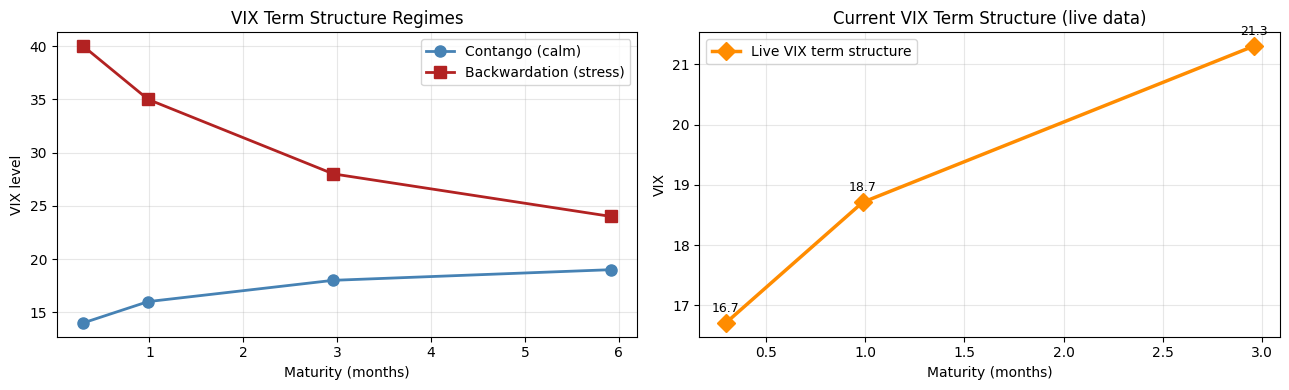

In [5]:
import yfinance as yf

# Fetch VIX term structure tickers
vix_specs = [('VIX9D', '^VIX9D', 9/365), ('VIX30', '^VIX', 30/365), ('VIX3M', '^VIX3M', 90/365)]
vix_levels = {}
for name, ticker, T in vix_specs:
    try:
        d = yf.download(ticker, period='5d', progress=False, auto_adjust=True)
        if len(d)>0:
            vix_levels[name] = (float(d['Close'].iloc[-1]), T)
    except:
        pass

# Simulate contango and backwardation regimes for illustration
T_vix = np.array([9, 30, 90, 180]) / 365
label_vix = ['9d', '30d', '3m', '6m']

contango     = np.array([14, 16, 18, 19])   # calm market
backwardation= np.array([40, 35, 28, 24])   # stressed market

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: simulated regimes
axes[0].plot(T_vix*12, contango,      'o-', lw=2, color='steelblue',  ms=8, label='Contango (calm)')
axes[0].plot(T_vix*12, backwardation, 's-', lw=2, color='firebrick',  ms=8, label='Backwardation (stress)')
axes[0].set_xlabel('Maturity (months)'); axes[0].set_ylabel('VIX level')
axes[0].set_title('VIX Term Structure Regimes')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Right: real VIX data (if available)
if vix_levels:
    names = list(vix_levels.keys())
    vals  = [vix_levels[n][0] for n in names]
    T_real= [vix_levels[n][1]*12 for n in names]
    axes[1].plot(T_real, vals, 'D-', lw=2.5, color='darkorange', ms=9, label='Live VIX term structure')
    for n, t, v in zip(names, T_real, vals):
        axes[1].annotate(f'{v:.1f}', (t, v), textcoords='offset points', xytext=(0,8), ha='center', fontsize=9)
    axes[1].set_xlabel('Maturity (months)'); axes[1].set_ylabel('VIX')
    axes[1].set_title('Current VIX Term Structure (live data)')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    slope = (vals[-1]-vals[0]) if len(vals)>=2 else 0
    regime = 'Contango' if slope>0 else 'Backwardation'
    print(f'Current regime: {regime}  (slope = {slope:+.1f} VIX pts from 9d to 3m)')
else:
    axes[1].text(0.5, 0.5, 'VIX data unavailable\n(showing simulated only)',
                ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
    axes[1].set_title('Current VIX Term Structure')

plt.tight_layout(); plt.show()

## 5. The Full Implied Volatility Surface

Stacking smile slices across maturities creates the **implied volatility surface**
$\sigma_{\text{imp}}(K, T)$ — or equivalently $\sigma_{\text{imp}}(\Delta, T)$ in delta space.

Practitioners need to **interpolate** between observed strikes and maturities.
Common approaches:
- **Spline in log-moneyness** per maturity slice, then interpolate parameters across $T$
- **SVI parameterization** (Chapter 10) — closed-form slice fit with arbitrage checks
- **Full parametric model** (Heston, SABR) — guarantees global arbitrage-free surface

The surface must satisfy **no-calendar-spread arbitrage**: total variance $w(k,T)=\sigma^2 T$
must be non-decreasing in $T$ for fixed $k$.

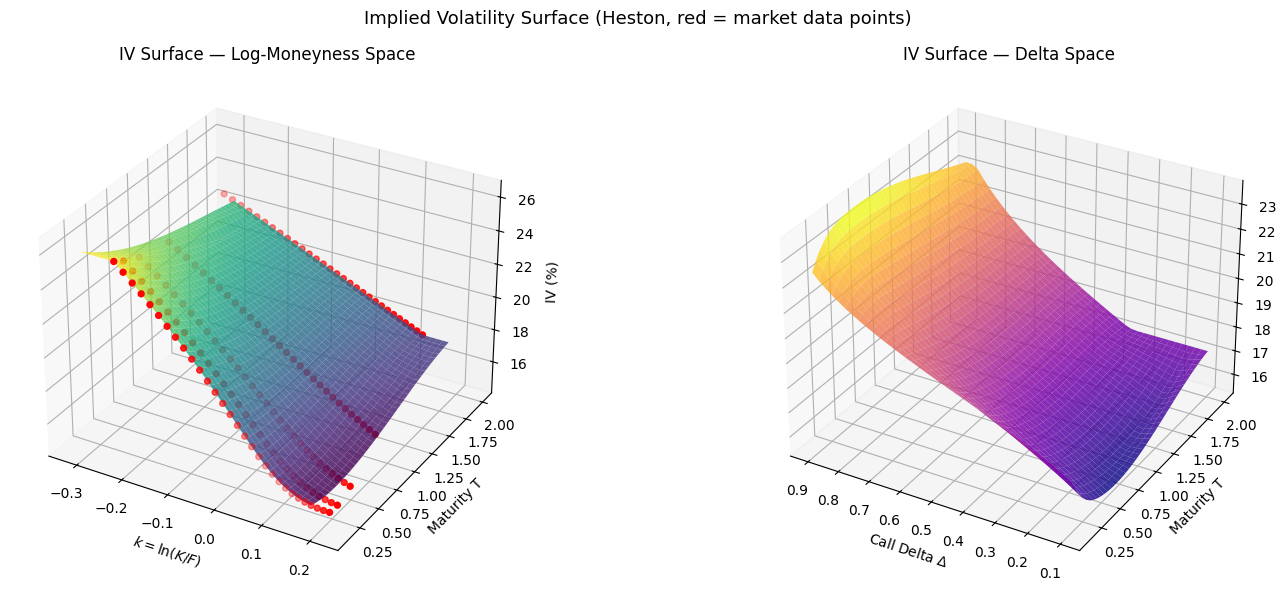

In [6]:
from mpl_toolkits.mplot3d import Axes3D

# Build IV on common k-grid for each maturity
k_common = np.linspace(-0.30, 0.18, 40)
T_arr    = np.array(maturities)
iv_grid  = np.zeros((len(maturities), len(k_common)))

for i, T_i in enumerate(maturities):
    _, k_i, iv_i = market_data[T_i]
    valid_i = np.isfinite(iv_i)
    iv_grid[i,:] = np.interp(k_common, k_i[valid_i], iv_i[valid_i])

# 2D spline interpolation
spline   = RectBivariateSpline(T_arr, k_common, iv_grid, kx=3, ky=3)
T_fine   = np.linspace(0.1, 2.0, 40)
K_mesh, T_mesh = np.meshgrid(k_common, T_fine)
iv_surf  = spline(T_fine, k_common)

# Convert delta for right panel
delta_grid = np.zeros_like(iv_grid)
for i, T_i in enumerate(maturities):
    for j, k_j in enumerate(k_common):
        K_j = S0*np.exp(r_f*T_i)*np.exp(k_j)
        iv_ij = iv_grid[i,j]
        delta_grid[i,j] = bs_delta(S0, K_j, r_f, T_i, iv_ij)

fig = plt.figure(figsize=(16, 6))

# Left: strike (k) space
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(K_mesh, T_mesh, iv_surf*100, cmap='viridis', alpha=0.82)
for T_i in maturities:
    _, k_i, iv_i = market_data[T_i]
    valid_i = np.isfinite(iv_i)
    ax1.scatter(k_i[valid_i], np.full(valid_i.sum(), T_i), iv_i[valid_i]*100,
               color='red', s=18, zorder=5)
ax1.set_xlabel(r'$k=\ln(K/F)$'); ax1.set_ylabel('Maturity T'); ax1.set_zlabel('IV (%)')
ax1.set_title('IV Surface — Log-Moneyness Space')

# Right: delta space
ax2 = fig.add_subplot(122, projection='3d')
d_common = np.linspace(0.10, 0.90, 40)
iv_delta_grid = np.zeros((len(maturities), len(d_common)))
for i, T_i in enumerate(maturities):
    idx_s = np.argsort(delta_grid[i,:])
    iv_delta_grid[i,:] = np.interp(d_common, delta_grid[i,idx_s], iv_grid[i,idx_s])
spline_d = RectBivariateSpline(T_arr, d_common, iv_delta_grid, kx=3, ky=3)
D_mesh, T_mesh2 = np.meshgrid(d_common, T_fine)
iv_surf_d = spline_d(T_fine, d_common)
ax2.plot_surface(D_mesh, T_mesh2, iv_surf_d*100, cmap='plasma', alpha=0.82)
ax2.set_xlabel('Call Delta $\Delta$'); ax2.set_ylabel('Maturity T'); ax2.set_zlabel('IV (%)')
ax2.set_title('IV Surface — Delta Space')
ax2.invert_xaxis()

plt.suptitle('Implied Volatility Surface (Heston, red = market data points)', fontsize=13)
plt.tight_layout(); plt.show()

## 6. Sticky-Strike vs. Sticky-Delta

When spot $S$ moves, which vol do you use to re-delta-hedge? Two regimes exist:

| Regime | Rule | Delta formula |
|--------|------|---------------|
| **Sticky-strike** | $\sigma_{\text{imp}}(K,T)$ fixed in $K$-space | $\Delta = \Delta_{\text{BS}}(\sigma_{\text{imp}}(K))$ |
| **Sticky-delta** | $\sigma_{\text{imp}}(\Delta,T)$ fixed in $\Delta$-space | $\Delta = \Delta_{\text{BS}}(\sigma_{\text{imp}}(\Delta))$ (smile moves with spot) |

Equivalently, sticky-delta = **sticky log-moneyness**: the smile in $k=\ln(K/F)$ is unchanged.
When spot moves $S\to S'$, the forward $F'=S'e^{rT}$ changes, so the strike at any given $k$
shifts to $K'=F'e^k$ — the whole smile translates in $K$-space.

**Equity markets** typically behave closer to sticky-strike in quiet periods and
sticky-delta after large moves.

Computing Heston at S0=105...

 done.


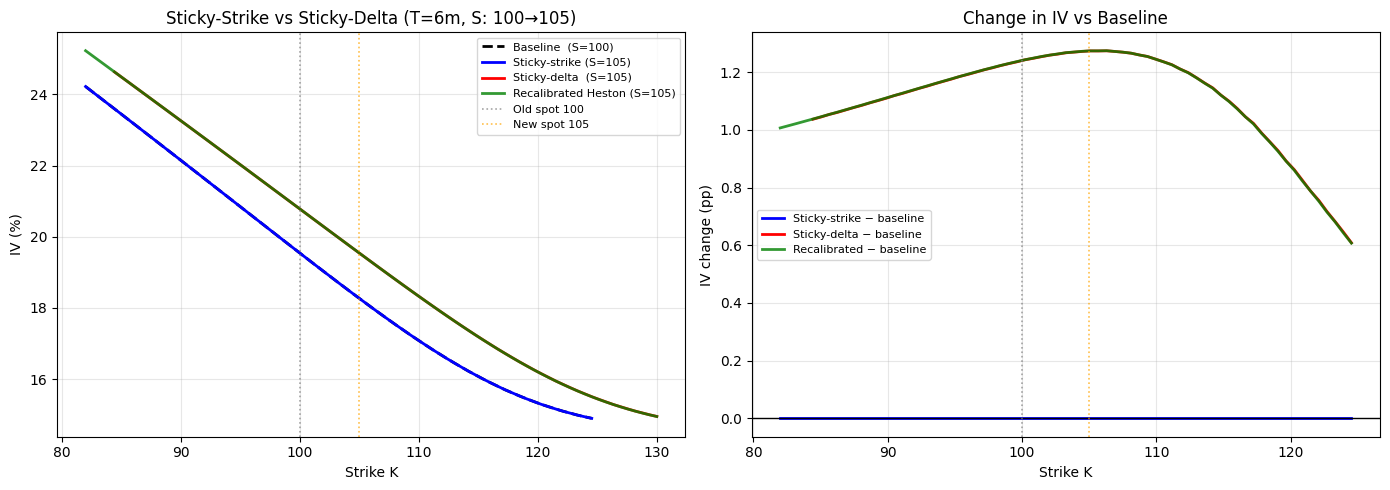

Key insight:
  Sticky-strike: smile is FIXED in K-space — put price unchanged at same K
  Sticky-delta:  smile SHIFTS right with spot — forward moneyness preserved


In [7]:
T_demo2 = 0.5
_, k_base, iv_base = market_data[T_demo2]
valid_b = np.isfinite(iv_base)

S0_new = 105.0   # spot moves +5%
F_old  = S0     * np.exp(r_f*T_demo2)
F_new  = S0_new * np.exp(r_f*T_demo2)

K_plot = np.linspace(82, 130, 80)

# Baseline IV(K) at S0=100
iv_bl  = np.interp(K_plot, strikes[valid_b], iv_base[valid_b], left=np.nan, right=np.nan)

# Sticky-strike: IV(K) unchanged
iv_ss  = iv_bl.copy()

# Sticky-delta: IV(k=ln(K/F_new)) = baseline IV(k=ln(K/F_new))
k_new_grid = np.log(K_plot / F_new)
k_sort_idx = np.argsort(k_base[valid_b])
k_bs = k_base[valid_b][k_sort_idx]
iv_bs= iv_base[valid_b][k_sort_idx]
iv_sd  = np.interp(k_new_grid, k_bs, iv_bs, left=np.nan, right=np.nan)

# Recalibrated Heston at S0_new=105
print('Computing Heston at S0=105...', end='', flush=True)
iv_rc = []
for Ki in K_plot:
    if Ki < S0_new:
        p=heston_put(S0_new, Ki, r_f, T_demo2, v0, kappa, theta, xi, rho_h)
        iv=implied_vol_newton(p, S0_new, Ki, r_f, T_demo2, is_call=False)
    else:
        p=heston_call(S0_new, Ki, r_f, T_demo2, v0, kappa, theta, xi, rho_h)
        iv=implied_vol_newton(p, S0_new, Ki, r_f, T_demo2, is_call=True)
    iv_rc.append(iv)
iv_rc = np.array(iv_rc)
print(' done.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: smile curves in K-space
ax = axes[0]
ax.plot(K_plot, iv_bl*100,  'k--', lw=2,   label='Baseline  (S=100)')
ax.plot(K_plot, iv_ss*100,  'b-',  lw=2,   label='Sticky-strike (S=105)')
ax.plot(K_plot, iv_sd*100,  'r-',  lw=2,   label='Sticky-delta  (S=105)')
ax.plot(K_plot, iv_rc*100,  'g-',  lw=2, alpha=0.8, label='Recalibrated Heston (S=105)')
ax.axvline(S0,    color='gray',   ls=':', lw=1.2, alpha=0.7, label='Old spot 100')
ax.axvline(S0_new,color='orange', ls=':', lw=1.2, alpha=0.7, label='New spot 105')
ax.set_xlabel('Strike K'); ax.set_ylabel('IV (%)')
ax.set_title('Sticky-Strike vs Sticky-Delta (T=6m, S: 100→105)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Right: difference from baseline
ax2 = axes[1]
ax2.plot(K_plot, (iv_ss-iv_bl)*100, 'b-', lw=2, label='Sticky-strike − baseline')
ax2.plot(K_plot, (iv_sd-iv_bl)*100, 'r-', lw=2, label='Sticky-delta − baseline')
ax2.plot(K_plot, (iv_rc-iv_bl)*100, 'g-', lw=2, alpha=0.8, label='Recalibrated − baseline')
ax2.axhline(0, color='black', lw=1)
ax2.axvline(S0,    color='gray',   ls=':', lw=1.2, alpha=0.7)
ax2.axvline(S0_new,color='orange', ls=':', lw=1.2, alpha=0.7)
ax2.set_xlabel('Strike K'); ax2.set_ylabel('IV change (pp)')
ax2.set_title('Change in IV vs Baseline')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

print('Key insight:')
print('  Sticky-strike: smile is FIXED in K-space — put price unchanged at same K')
print('  Sticky-delta:  smile SHIFTS right with spot — forward moneyness preserved')

## 7. Real SPY Option Data

We fetch live SPY option chains to see these patterns in actual market data.
For each expiry we compute mid-price implied volatilities, filter to liquid strikes,
and plot the surface alongside the Heston reference.

> **Note:** Market IVs include bid-ask spread costs, discrete dividends, and microstructure
> effects — expect more noise than the Heston model surface.

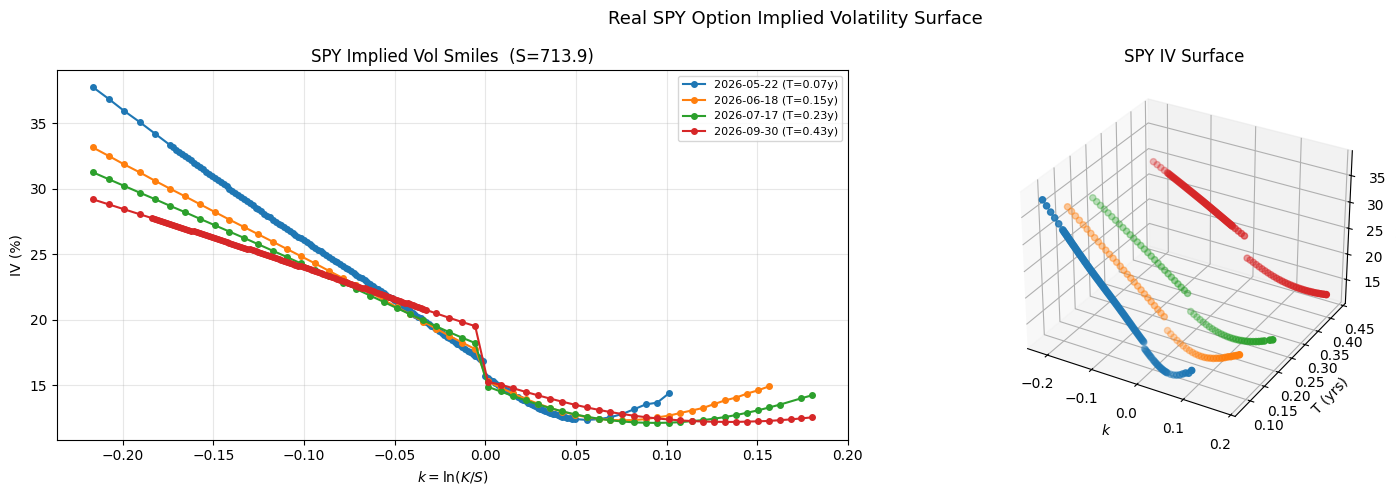

Fetched 4 expiries  |  S_spy = 713.94


In [8]:
import pandas as pd
from datetime import datetime
from datetime import date as date_cls

try:
    spy_ticker = yf.Ticker('SPY')
    S_spy = float(spy_ticker.history(period='2d')['Close'].iloc[-1])
    expirations = spy_ticker.options   # tuple of date strings
    today = date_cls.today()

    # Select 4 expiries near 1m, 2m, 3m, 6m
    targets = [30, 60, 90, 180]
    exp_sel = []
    for tgt in targets:
        best, bdiff = None, 9999
        for exp_str in expirations:
            dte = (datetime.strptime(exp_str, '%Y-%m-%d').date() - today).days
            if abs(dte - tgt) < bdiff:
                best, bdiff = exp_str, abs(dte - tgt)
        if best and best not in exp_sel:
            exp_sel.append(best)

    r_spy = 0.05
    spy_smiles = {}
    for exp_str in exp_sel:
        T = (datetime.strptime(exp_str, '%Y-%m-%d').date() - today).days / 365.0
        if T < 0.02:
            continue
        chain = spy_ticker.option_chain(exp_str)
        pairs = []
        for is_call, tbl in [(True, chain.calls), (False, chain.puts)]:
            if tbl is None or tbl.empty:
                continue
            for _, row in tbl.iterrows():
                K = float(row['strike'])
                lo, hi = (1.00, 1.20) if is_call else (0.80, 1.00)
                if not (lo * S_spy < K < hi * S_spy):
                    continue
                bid_val = row.get('bid') if hasattr(row, 'get') else row['bid']
                ask_val = row.get('ask') if hasattr(row, 'get') else row['ask']
                if pd.isna(bid_val) or float(bid_val) < 0.05:
                    continue
                mid = (float(bid_val) + float(ask_val)) / 2 if not pd.isna(ask_val) else float(bid_val)
                iv = implied_vol_newton(mid, S_spy, K, r_spy, T, is_call=is_call)
                if iv is not None and not pd.isna(iv) and 0.05 < iv < 1.5:
                    pairs.append((K, iv))
        if len(pairs) >= 4:
            pairs.sort()
            spy_smiles[exp_str] = (np.array([p[0] for p in pairs]),
                                   np.array([p[1] for p in pairs]), T)

    if not spy_smiles:
        raise ValueError('No liquid option data found')

    fig = plt.figure(figsize=(16, 5))

    ax1 = fig.add_subplot(121)
    for exp_str, (Ks, ivs_spy, T) in spy_smiles.items():
        k = np.log(Ks / S_spy)
        ax1.plot(k, ivs_spy * 100, 'o-', ms=4, lw=1.5, label=f'{exp_str} (T={T:.2f}y)')
    ax1.set_xlabel(r'$k=\ln(K/S)$')
    ax1.set_ylabel('IV (%)')
    ax1.set_title(f'SPY Implied Vol Smiles  (S={S_spy:.1f})')
    ax1.legend(fontsize=8)
    ax1.grid(alpha=0.3)

    ax2 = fig.add_subplot(122, projection='3d')
    for exp_str, (Ks, ivs_spy, T) in spy_smiles.items():
        k = np.log(Ks / S_spy)
        ax2.scatter(k, np.full_like(k, T), ivs_spy * 100, s=20)
    ax2.set_xlabel(r'$k$')
    ax2.set_ylabel('T (yrs)')
    ax2.set_zlabel('IV (%)')
    ax2.set_title('SPY IV Surface')

    plt.suptitle('Real SPY Option Implied Volatility Surface', fontsize=13)
    plt.tight_layout()
    plt.show()
    print(f'Fetched {len(spy_smiles)} expiries  |  S_spy = {S_spy:.2f}')

except Exception as e:
    print(f'Could not fetch SPY options: {e}')
    print('Showing Heston reference surface instead.')
    fig, ax = plt.subplots(figsize=(10, 5))
    for T_i in maturities:
        _, k_i, iv_i = market_data[T_i]
        v = np.isfinite(iv_i)
        ax.plot(k_i[v], iv_i[v] * 100, 'o-', ms=3, lw=1.5, label=f'T={T_i}')
    ax.set_xlabel(r'$k=\ln(K/F)$')
    ax.set_ylabel('IV (%)')
    ax.set_title('Heston IV Surface (fallback — SPY data unavailable)')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Summary

The implied volatility surface $\sigma_{\text{imp}}(K, T)$ encodes the market's entire view
of future uncertainty across strikes and maturities.

| Concept | Key takeaway |
|---------|-------------|
| **Smile/skew** | OTM puts expensive (equity fear); BS flat-vol assumption fails |
| **Delta space** | Portable quoting convention independent of spot level |
| **RR25** | Measures skew: $<0$ means put premium; steeper short-dated |
| **BF25** | Measures curvature: $>0$ means smile; grows with maturity |
| **VIX term structure** | Contango = calm; backwardation = near-term stress |
| **Sticky-strike** | Vol fixed at same $K$; smile shifts in $\Delta$-space when spot moves |
| **Sticky-delta** | Vol fixed at same $\Delta$; smile shifts in $K$-space with spot |

### Connection to Earlier Chapters

- **Ch. 7 (Merton)**: jump-diffusion generates left skew and excess kurtosis in the smile
- **Ch. 9 (Heston)**: stochastic vol generates a richer, term-structure-aware surface
- **Ch. 10 (SVI)**: parsimonious fit to observed smiles with no-arbitrage guarantees
- **Ch. 11 (GARCH)**: realized-vol forecast vs. implied-vol risk premium from the surface

Together, these chapters form a complete picture from theoretical models to market practice.